In [1]:
from galaxy_datasets import gz_candels 
    
catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [2]:
catalog.columns.to_numpy()

array(['smooth-or-featured-candels_smooth',
       'smooth-or-featured-candels_features',
       'smooth-or-featured-candels_artifact',
       'how-rounded-candels_completely', 'how-rounded-candels_in-between',
       'how-rounded-candels_cigar-shaped',
       'clumpy-appearance-candels_yes', 'clumpy-appearance-candels_no',
       'clump-count-candels_1', 'clump-count-candels_2',
       'clump-count-candels_3', 'clump-count-candels_4',
       'clump-count-candels_5-plus', 'clump-count-candels_cant-tell',
       'disk-edge-on-candels_yes', 'disk-edge-on-candels_no',
       'edge-on-bulge-candels_yes', 'edge-on-bulge-candels_no',
       'bar-candels_yes', 'bar-candels_no', 'has-spiral-arms-candels_yes',
       'has-spiral-arms-candels_no', 'spiral-winding-candels_tight',
       'spiral-winding-candels_medium', 'spiral-winding-candels_loose',
       'spiral-arm-count-candels_1', 'spiral-arm-count-candels_2',
       'spiral-arm-count-candels_3', 'spiral-arm-count-candels_4',
       'spiral

In [3]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
from torchvision.transforms import ToTensor
import torch
gzdataset = GalaxyDataset(
    catalog,
    label_cols=['merging-candels_merger'],  
    transform=ToTensor(),
    target_transform=lambda x: torch.tensor(x, dtype=torch.float32),
    )

tensor(6.)
torch.Size([3, 424, 424])


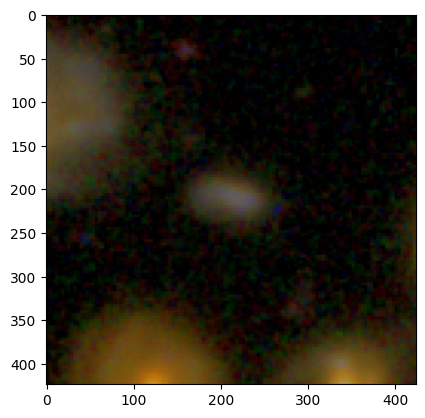

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_rgb, AsinhStretch
from torchvision.transforms import ToPILImage
img, labels = gzdataset[np.random.randint(len(gzdataset))]
plt.imshow(ToPILImage()(img))
print(labels)
print(img.shape)

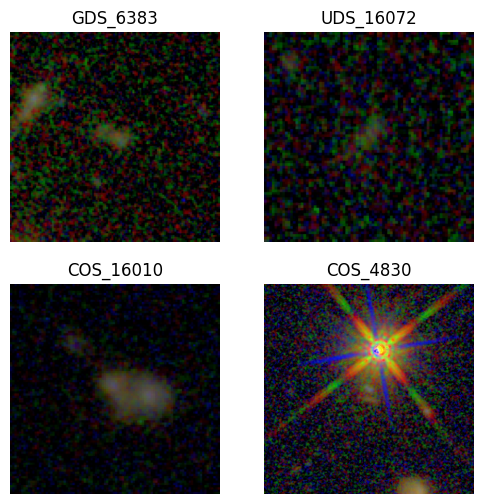

In [5]:
from ml_sandbox.dataset import show_sample_images
for i in range(3,4):
    show_sample_images(gzdataset, num_images=i+1)

In [6]:
from torch.utils.data import random_split
train_dataset, test_dataset = random_split(gzdataset, [0.8, 0.2])

In [7]:
from ml_sandbox.models import SimpleCNNClassifier
from ml_sandbox.train_eval import train_cnn, test_cnn
from ml_sandbox.dataset import get_dataloader
model = SimpleCNNClassifier(num_classes=2, input_channels=3, side=424)
train_loader = get_dataloader(train_dataset, batch_size=32)
test_loader = get_dataloader(test_dataset, batch_size=32)

from torch.nn import BCEWithLogitsLoss
criterion = BCEWithLogitsLoss()

from torch.optim import Adam
optimizer = Adam(model.parameters(), lr=1e-3)

In [8]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    print(labels)
    break

torch.Size([32, 3, 424, 424]) torch.Size([32])
tensor([ 3.,  1.,  0.,  0.,  1.,  1.,  1.,  5.,  3., 13.,  1.,  1.,  1.,  1.,
         0.,  8.,  4.,  1., 39.,  1.,  1., 23.,  1.,  0., 10.,  1.,  0.,  1.,
        22., 19.,  1.,  1.])


In [ ]:
for images, labels in train_loader:
    print(model(images), labels)
    break

In [9]:
for _ in range(5):
    train_cnn(train_loader, model, criterion, optimizer) 
    test_cnn(test_loader, model, criterion)

ValueError: Target size (torch.Size([32])) must be the same as input size (torch.Size([32, 2]))

In [35]:
106*106*32

359552

In [7]:
from ml_sandbox.models import make_pca_rf_pipeline
model = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [8]:
from ml_sandbox.dataset import get_sklearn_dataset
from sklearn.model_selection import train_test_split
X, y = get_sklearn_dataset(catalog, label_cols='merging-candels_merger')

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
import torchvision
from torchvision.transforms import ToTensor

In [8]:
model.fit(xtrain, ytrain)
test_accuracy = model.score(xtest, ytest)
print(f'Test Accuracy: {test_accuracy:.4f}')


ValueError: could not convert string to float: 'GDS_2171.jpg'